# priya_loader — quick-start (real PRIYA data)

`priya_loader` turns the PRIYA MP-Gadget Lyman-α simulation suite into ML-ready
3-D numpy arrays. `PriyaDataset` loops over every (simulation, redshift) and
yields a `Sample` carrying **`[SimParams, redshift, IC density δ₁, τ]`**.

**This notebook uses the real staged suite — there are no synthetic fixtures.**
It requires the PRIYA simulations on disk; if you don't have access to PRIYA,
this package isn't for you. Set `ROOT` below to your suite root (the directory
holding the parameter-named simulation folders).

> Built on Great Lakes, where the **τ** products are staged but the **IC**
> particle data is not (the `ICS/` trees are empty skeletons). So the τ / params
> / dataset sections below run on real data; the **IC sections are the NERSC
> job** — see §4 and §6.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import priya_loader as pl
from priya_loader import (discover_simulations, SimParams, load_tau_grid,
                          load_ic_density, load_ic_particles, PriyaDataset, to_flux)

# >>> set this to YOUR PRIYA suite root <<<
ROOT = "/scratch/cavestru_root/cavestru0/mfho/priya/emu_full"
print("priya_loader", pl.__version__, "| ROOT exists:", Path(ROOT).is_dir())

priya_loader 0.2.0.dev0 | ROOT exists: True


## 1. Discover simulations & read parameters

`discover_simulations` walks the suite; `SimParams.from_dir` reads the
cosmology/thermal parameters and takes box & Ngrid from the **authoritative run
files** (`mpgadget.param` / `_genic_params.ini`), not the often-stale
`SimulationICs.json`. Below we read every sim and plot the suite's parameter
coverage (`n_s` vs the primordial amplitude `A_p`) — a real view of the emulator
design.

discovered 60 simulations
example: ns0.803Ap2.2e-09herei4.05heref2.67alphaq2.21hu ...
  box, npart: 120.0 Mpc/h , 1536  fidelity: lowres  z: [2.0, 99.0]
parameters read for 60 / 60 sims


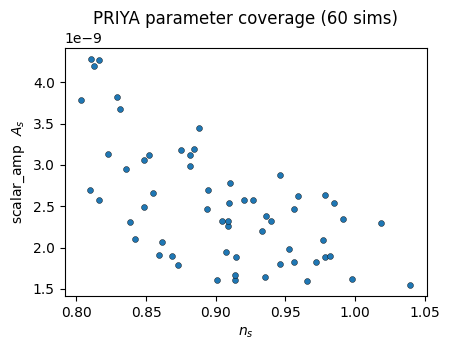

In [2]:
sims = discover_simulations(ROOT)
print("discovered", len(sims), "simulations")
p0 = SimParams.from_dir(sims[0].directory)
print("example:", p0.name[:46], "...")
print("  box, npart:", p0.box, "Mpc/h ,", p0.npart, " fidelity:", p0.fidelity,
      " z:", [p0.z_end, p0.z_init])

ns, Ap, ok = [], [], 0
for s in sims:
    try:
        p = SimParams.from_dir(s.directory)
        v = p.as_vector(["ns", "scalar_amp"])
        ns.append(v[0]); Ap.append(v[1]); ok += 1
    except Exception:
        pass
print("parameters read for", ok, "/", len(sims), "sims")
plt.figure(figsize=(4.6, 3.6))
plt.scatter(ns, Ap, s=18, c="C0", edgecolors="k", linewidths=0.3)
plt.xlabel(r"$n_s$"); plt.ylabel("scalar_amp  $A_s$")
plt.title(f"PRIYA parameter coverage ({ok} sims)"); plt.tight_layout(); plt.show()

## 2. Optical depth `τ` → flux (real)

`load_tau_grid(path, axis)` returns the **raw** τ cube for one line-of-sight axis
as `(ngrid, ngrid, nbins)` — two transverse indices and one LOS (velocity) index,
redshift-space, never rebinned. `F = exp(−τ)` is the transmitted flux: dark where
τ is large (dense filaments), bright in the voids. One axis is ~1.5 GB.

tau: (480, 480, 1434)  z = 4.3999999999999995  box = 120.0 Mpc/h  cube_axes = ('x', 'y', 'z')  nbins = 1434  dv_kms = 10.01
mean flux (this slice): 0.271  | tau slice max: 1.05e+08 (a saturated DLA trough)


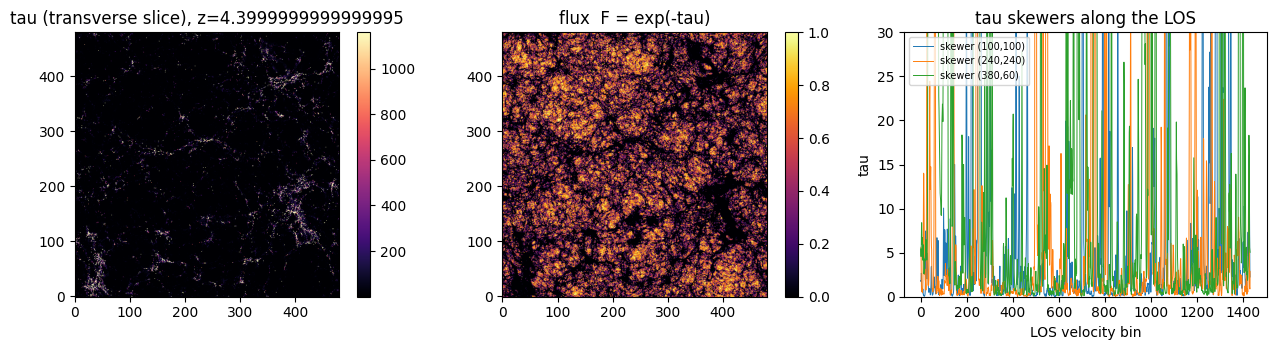

In [3]:
spec = next((ROOT and Path(ROOT)/sims[0].directory.name/"output").glob("SPECTRA_*"))
fpath = spec / "lya_forest_spectra_grid_480.hdf5"
g = load_tau_grid(fpath, axis=3)            # axis 3: cube_axes = (x, y, z)
print("tau:", g.tau.shape, " z =", g.redshift, " box =", g.box, "Mpc/h",
      " cube_axes =", g.cube_axes, " nbins =", g.nbins, " dv_kms =", round(g.meta["dv_kms"], 2))

b = g.nbins // 2
tau_sl = g.tau[:, :, b]; flux_sl = np.exp(-tau_sl)
print("mean flux (this slice):", round(float(flux_sl.mean()), 3),
      " | tau slice max:", f"{float(tau_sl.max()):.2e}", "(a saturated DLA trough)")
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
im0 = ax[0].imshow(tau_sl, origin="lower", cmap="magma", vmax=np.percentile(tau_sl, 99))
ax[0].set_title(f"tau (transverse slice), z={g.redshift}"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(flux_sl, origin="lower", cmap="inferno", vmin=0, vmax=1)
ax[1].set_title("flux  F = exp(-tau)"); fig.colorbar(im1, ax=ax[1])
for (i, j) in [(100, 100), (240, 240), (380, 60)]:
    ax[2].plot(g.tau[i, j, :], lw=0.7, label=f"skewer ({i},{j})")
ax[2].set_title("tau skewers along the LOS"); ax[2].set_xlabel("LOS velocity bin")
ax[2].set_ylabel("tau"); ax[2].set_ylim(0, 30); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()
del g, tau_sl, flux_sl

## 3. `PriyaDataset` — the headline loop (real, graceful)

Iterating yields `Sample(params, redshift, ic, tau)` lazily, one (sim, z) at a
time. On this Great Lakes scratch the IC trees are empty skeletons, so the loader
**degrades gracefully**: you get real τ with `ic = None` and a warning — exactly
how it handles a partially-staged suite. (On NERSC with ICs staged, `s.ic` is the
real δ₁/CIC cube.)

In [4]:
import warnings
ds = PriyaDataset(ROOT, ic_nmesh=256, ic_field="icdensity", flux_axis=3)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    s = next(iter(ds))                       # first (sim, z): loads real tau, tries IC
print("Sample:")
print("  params:", s.params.name[:40], "...")
print("  redshift:", s.redshift)
print("  tau:", None if s.tau is None else s.tau.shape, "(real)")
print("  ic :", s.ic, "(None: ICs not staged here -> the NERSC job)")
print("  as_tuple length:", len(s.as_tuple()))
del s

Sample:
  params: ns0.803Ap2.2e-09herei4.05heref2.67alphaq ...
  redshift: 5.4
  tau: (480, 480, 1556) (real)
  ic : None (None: ICs not staged here -> the NERSC job)
  as_tuple length: 4


## 4. Initial conditions — **the NERSC job**

IC particle data is **not staged on Great Lakes** (every `ICS/<box>_<Ngrid>_99/`
is a ~26 KB empty skeleton), so the cells below are shown as the API you'll run
on NERSC where the bigfiles are staged. None of this is executed here — there is
no synthetic stand-in.

```python
ICDIR = Path(ROOT) / sims[0].directory.name / "ICS" / "120_1536_99"

# 4a. Linear delta_1 (recommended for the bias cross-spectrum) — no CIC.
#     nmesh must DIVIDE ngrid (256/384/512 | 1536, 3072); never 480 with icdensity.
lin = load_ic_density(ICDIR, ptype="dm", nmesh=512, field="icdensity")   # (512,512,512) delta_1

# 4b. Raw particle columns (mesh with your own nbodykit / Pylians).
data, header = load_ic_particles(ICDIR, ptype="dm",
                                 columns=("Position", "ICDensity", "ID"))

# 4c. Eulerian CIC density (built-in numpy CIC; verified vs an explicit
#     reference and vs Pylians on synthetic points — NOT yet on real ICs).
cic = load_ic_density(ICDIR, ptype="dm", nmesh=480, field="cic")
```

The first thing to do on NERSC is a **real-IC smoke test**: confirm
`load_ic_density(ICDIR, field="icdensity", nmesh=512)` reads a staged 1536³
bigfile and that `δ₁` looks like a Gaussian random field (the MP-GenIC
realization of the CLASS linear P(k)). That is the one code path never exercised
on real data.

## 5. Co-registration & growth — the consumer's job

The loader only *loads*; for the bias cross-spectrum
`b_F = P_{F,δ₁}/P_{δ₁δ₁}` you then:

- **rescale** δ₁ from z_init≈99 to the flux redshift by `D(z_flux)/D(99)`
  (`priya_loader.units.growth_factor`);
- **co-register** with the anisotropic τ cube. The τ axis you loaded above is
  `axis=3`, whose `cube_axes = (x, y, z)` is the identity; **axes 1 and 2 are
  permuted** (`(y,z,x)` / `(x,z,y)`), so transpose δ₁ to `g.cube_axes` before
  crossing or `b_F → 0`. With `field="cic"` paint at `nmesh=480` to match the τ
  transverse grid; with `field="icdensity"` load at a **divisor** of `ngrid` and
  Fourier-match the common low-`k` modes;
- **deconvolve** the IC window (CIC `sinc²`, or the `icdensity` block-average
  `sinc`);
- pick the **mean-flux** normalisation and the **DLA** treatment (the raw τ above
  keeps the saturated `τ>1e6` troughs) for `δ_F`.

See `HANDOFF.md` for the full recommended path.

## 6. To finish on NERSC

- [ ] **Stage / point at real ICs** and run the §4 cells; add the real δ₁ and
      CIC figures (cosmic-web structure), mirroring the real τ figure above.
- [ ] **Real-IC smoke test** for `field="icdensity"` and `field="cic"` on a
      staged 1536³ (and 3072³ hires) bigfile.
- [ ] **Live flux–density cross-correlation**: load δ₁ (axis-3-aligned) and the
      flux, show the anti-correlation and a measured `b_F = ⟨δ_F δ₁⟩/⟨δ₁²⟩`.
- [ ] Confirm the full **z range** of staged τ per sim (`find_spectra_files`).

Swapping `ROOT` is all that changes between machines — paths are never
hard-coded in the package.